# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [34]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import datetime as dt

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [6]:
datalink ="https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv"


### Step 3. Assign it to a variable apple

In [8]:
df = pd.read_csv(datalink)

In [25]:
df.shape

(8465, 6)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8465 entries, 2014-07-08 to 1980-12-12
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       8465 non-null   float64
 1   High       8465 non-null   float64
 2   Low        8465 non-null   float64
 3   Close      8465 non-null   float64
 4   Volume     8465 non-null   int64  
 5   Adj Close  8465 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 721.0 KB


In [9]:
df.head(5)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 4.  Check out the type of the columns

In [14]:
print(df.dtypes)

print(df['Date'].dtype)# object cause it's a mixed data type



Date          object
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object
object


### Step 5. Transform the Date column as a datetime type

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
#ممكن مكنش يظبط مع فورماتنج مختلف مثلا لو موجود فيه وقت بالساعات 
# df['Date'] = pd.to_datetime(df['Date'] , format = '%y-%m-%d %i-%p')
# في الحاله دي هعدل الفورمات

In [16]:
print(df['Date'].dtype)

datetime64[ns]


### Step 6.  Set the date as the index

In [17]:
df.set_index("Date", inplace=True)

In [18]:
df.head(5)

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 7.  Is there any duplicate dates?

In [28]:
if df.index.duplicated().any():
    print(f"duplicates found : " )
    duplicates = df[df.index.duplicated()]
    print(duplicates)

else:
    print("no duplicates found")


no duplicates found


### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [29]:
#sorting from oldest date to newest 

df.sort_index(ascending=True)

#if date wasn't index
#df.sort_values(by='Date', ascending=True)

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41
...,...,...,...,...,...,...
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03


### Step 9. Get the last business day of each month

In [32]:
last_BD_of_M= df.resample('BM').last()
print(f"last business day of each month :\n {last_BD_of_M} ")

last business day of each month :
               Open    High     Low   Close     Volume  Adj Close
Date                                                            
1980-12-31   34.25   34.25   34.13   34.13    8937600       0.53
1981-01-30   28.50   28.50   28.25   28.25   11547200       0.44
1981-02-27   26.50   26.75   26.50   26.50    3690400       0.41
1981-03-31   24.75   24.75   24.50   24.50    3998400       0.38
1981-04-30   28.38   28.62   28.38   28.38    3152800       0.44
...            ...     ...     ...     ...        ...        ...
2014-03-31  539.23  540.81  535.93  536.74   42167300      76.25
2014-04-30  592.64  599.43  589.80  590.09  114160200      83.83
2014-05-30  637.98  644.17  628.90  633.00  141005200      90.43
2014-06-30   92.10   93.73   92.09   92.93   49482300      92.93
2014-07-31   96.27   96.80   93.92   95.35   65130000      95.35

[404 rows x 6 columns] 


C:\Users\Soft Key\AppData\Local\Temp\ipykernel_24268\1700863937.py:1: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  last_BD_of_M= df.resample('BM').last()


### Step 10.  What is the difference in days between the first day and the oldest

In [24]:
print(df.index.min())
print(df.index.max())

print(df.index.max()-df.index.min())

1980-12-12 00:00:00
2014-07-08 00:00:00
12261 days 00:00:00


### Step 11.  How many months in the data we have?

In [47]:
no_month=df.resample('M').count()
print(len(no_month))



404


C:\Users\Soft Key\AppData\Local\Temp\ipykernel_24268\1085952061.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  no_month=df.resample('M').count()


### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

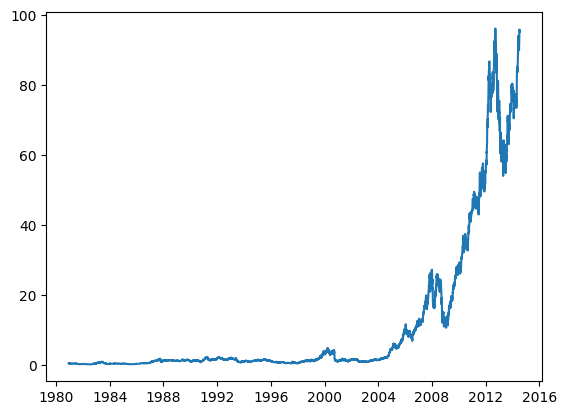

In [46]:
x = df.index
y = df['Adj Close']

plt.plot(x,y)